# Walmart Store Sales — LightGBM Training


In [17]:
!pip install lightgbm mlflow matplotlib seaborn

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikadurishvili/walmart-preprocessing/walmart_preprocessing.py
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [19]:
import os
import sys
import json

import numpy as np
import pandas as pd
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath("."))
import sys

sys.path.append("/kaggle/input/datasets/nikadurishvili/walmart-preprocessing")

from walmart_preprocessing import build_dataset

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

print("lightgbm:", lgb.__version__)
print("mlflow  :", mlflow.__version__)

lightgbm: 4.6.0
mlflow  : 3.14.0


# Build the dataset


In [20]:
BASE_PATH = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"
VAL_WEEKS = 8

ds = build_dataset(base_path=BASE_PATH, val_weeks=VAL_WEEKS, verbose=True)

X_tr, y_tr   = ds.X_tr, ds.y_tr
X_val, y_val = ds.X_val, ds.y_val
X_test       = ds.X_test
w_val        = ds.w_val
FEATURES     = ds.features

print(f"\nFinal feature count: {len(FEATURES)}")
print(f"X_tr={X_tr.shape}  X_val={X_val.shape}  X_test={X_test.shape}")

Step 1/7 · Loading raw data…
  train=(421570, 5)  test=(115064, 4)  stores=(45, 3)  features=(8190, 12)
Step 2/7 · Merging tables…
  Combined shape: (536634, 17)
Step 3/7 · Creating train / val / test masks…
  Train=397,841  Val=23,729  Test=115,064
Step 4/7 · Cleaning target (train only)…
  Post-clean range: -25.9 – 283,843.0
Step 5/7 · Engineering features…
  Columns after feature engineering: 140
Step 6/7 · Cleaning features…
  Features after cleaning: 100
Step 7/7 · Selecting features…
[select_features] |r| > 0.9 vs target — review:
  store_dept_median                              r=0.9655
  roll_max_4w                                    r=0.9138
  Final feature count: 80

  X_tr=(397841, 80)  X_val=(23729, 80)  X_test=(115064, 80)
  Done ✓

Final feature count: 80
X_tr=(397841, 80)  X_val=(23729, 80)  X_test=(115064, 80)


## Evaluation metric — WMAE


In [21]:
def wmae(y_true, y_pred, weights):
    return np.average(np.abs(np.asarray(y_true) - np.asarray(y_pred)), weights=weights)

w_tr = (
    ds.df.loc[ds.tr_mask, "IsHoliday"]
    .astype(float)
    .map({1.0: 5.0, 0.0: 1.0})
    .reset_index(drop=True)
)

In [22]:
def safe_log1p(y):
    return np.log1p(np.clip(y, a_min=0, a_max=None))

y_tr_log  = safe_log1p(y_tr.values)
y_val_log = safe_log1p(y_val.values)

## MLflow experiment setup


In [23]:
!pip install dagshub

In [24]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="nikaduri",
    repo_name="ml-store-sales-forecasting",
    mlflow=True,
)

EXPERIMENT_NAME = "lightgbm_training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment:   {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a8e2a860-454b-406a-ae2d-7e0ec2973a65&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=720d3ac164f465e1ea851f4ad46e9e062b85989792ae75810c0a2fe83b2b0448




Output()

Accessing as nikaduri

Initialized MLflow to track repo "nikaduri/ml-store-sales-forecasting"

Repository nikaduri/ml-store-sales-forecasting initialized!

2026/07/06 09:53:40 INFO mlflow.tracking.fluent: Experiment with name 'lightgbm_training' does not exist. Creating a new experiment.


Tracking URI: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow
Experiment:   lightgbm_training


## Randomized hyperparameter search


In [25]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import randint, uniform

N_SEARCH_ITER = 15      
RANDOM_SEARCH_SEED = 42

# num_leaves replaces max_depth as the primary complexity control — LightGBM grows
# leaf-wise (best-first), so max_depth alone barely constrains it. max_depth is fixed
# at -1 (unconstrained) below, and num_leaves does the regularizing work instead.
#
# min_child_samples (min_data_in_leaf) gets its own search dimension since leaf-wise
# growth is more prone to carving out tiny, high-variance leaves than depth-wise growth.
#
# min_split_gain is LightGBM's analogue of XGBoost's gamma.
param_distributions = {
    "num_leaves": randint(16, 256),
    "learning_rate": uniform(0.01, 0.09),      # 0.01 - 0.10
    "n_estimators": randint(500, 3001),
    "subsample": uniform(0.6, 0.35),           # 0.60 - 0.95 (bagging_fraction)
    "colsample_bytree": uniform(0.5, 0.45),    # 0.50 - 0.95 (feature_fraction)
    "min_child_samples": randint(5, 100),      # min_data_in_leaf
    "reg_alpha": uniform(0.0, 1.0),
    "reg_lambda": uniform(0.5, 2.5),
    "min_split_gain": uniform(0.0, 0.3),
}

INT_PARAMS = {"num_leaves", "n_estimators", "min_child_samples"}

sampled_params = list(ParameterSampler(
    param_distributions, n_iter=N_SEARCH_ITER, random_state=RANDOM_SEARCH_SEED
))

HYPERPARAM_CONFIGS = [
    {
        "run_name": f"search_{i:02d}",
        "params": {k: (int(v) if k in INT_PARAMS else float(round(v, 4)))
                   for k, v in p.items()},
    }
    for i, p in enumerate(sampled_params)
]

print(f"Sampled {len(HYPERPARAM_CONFIGS)} random hyperparameter configurations:")
for cfg in HYPERPARAM_CONFIGS[:5]:
    print(" ", cfg["run_name"], cfg["params"])
print("  ...")

Sampled 15 random hyperparameter configurations:
  search_00 {'colsample_bytree': 0.6685, 'learning_rate': 0.0956, 'min_child_samples': 76, 'min_split_gain': 0.1796, 'n_estimators': 2138, 'num_leaves': 137, 'reg_alpha': 0.156, 'reg_lambda': 0.6452, 'subsample': 0.9032}
  search_01 {'colsample_bytree': 0.7705, 'learning_rate': 0.0737, 'min_child_samples': 26, 'min_split_gain': 0.0169, 'n_estimators': 2891, 'num_leaves': 251, 'reg_alpha': 0.9386, 'reg_lambda': 0.5019, 'subsample': 0.9473}
  search_02 {'colsample_bytree': 0.7779, 'learning_rate': 0.065, 'min_child_samples': 93, 'min_split_gain': 0.0874, 'n_estimators': 1582, 'num_leaves': 185, 'reg_alpha': 0.0467, 'reg_lambda': 2.9344, 'subsample': 0.6815}
  search_03 {'colsample_bytree': 0.5408, 'learning_rate': 0.0657, 'min_child_samples': 59, 'min_split_gain': 0.295, 'n_estimators': 2028, 'num_leaves': 146, 'reg_alpha': 0.8599, 'reg_lambda': 2.2008, 'subsample': 0.7577}
  search_04 {'colsample_bytree': 0.506, 'learning_rate': 0.0948, '

## Training loop — one MLflow run per sampled configuration

In [26]:
EARLY_STOPPING_ROUNDS = 50

import time
from mlflow.entities import Metric

def log_curve_batched(key, values, run_id, chunk_size=1000):
    ts = int(time.time() * 1000)
    metrics = [Metric(key=key, value=float(v), timestamp=ts, step=i)
               for i, v in enumerate(values)]
    client = mlflow.tracking.MlflowClient()
    for start in range(0, len(metrics), chunk_size):
        client.log_batch(run_id=run_id, metrics=metrics[start:start + chunk_size])

results = []
eval_histories = {}
models = {}

for cfg in HYPERPARAM_CONFIGS:
    run_name = cfg["run_name"]
    params = cfg["params"]

    with mlflow.start_run(run_name=run_name) as run:
        model = lgb.LGBMRegressor(
            objective="regression",
            metric="mae",
            max_depth=-1,              
            bagging_freq=1,          
            importance_type="gain",
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
            **params,
        )

        model.fit(
            X_tr, y_tr_log,
            sample_weight=w_tr,
            eval_set=[(X_tr, y_tr_log), (X_val, y_val_log)],
            eval_names=["train", "valid"],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                       lgb.log_evaluation(0)],
        )

        val_pred = np.expm1(model.predict(X_val))
        tr_pred  = np.expm1(model.predict(X_tr))

        val_wmae   = wmae(y_val.values, val_pred, w_val.values)
        train_wmae = wmae(y_tr.values, tr_pred, w_tr.values)
        val_mae    = mean_absolute_error(y_val, val_pred)
        val_rmse   = float(np.sqrt(mean_squared_error(y_val, val_pred)))
        val_r2     = r2_score(y_val, val_pred)
        tr_mae     = mean_absolute_error(y_tr, tr_pred)
        best_iter  = model.best_iteration_

        # --- MLflow logging ---
        mlflow.log_params(params)
        mlflow.log_param("early_stopping_rounds", EARLY_STOPPING_ROUNDS)
        mlflow.log_param("n_features", len(FEATURES))
        mlflow.log_param("val_weeks", VAL_WEEKS)
        mlflow.log_param("best_iteration", best_iter)
        mlflow.log_param("log1p_target", True)

        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("val_mae", val_mae)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("val_r2", val_r2)
        mlflow.log_metric("train_mae", tr_mae)

        history = model.evals_result_
        log_curve_batched("train_mae_curve", history["train"]["l1"], run.info.run_id)
        log_curve_batched("val_mae_curve", history["valid"]["l1"], run.info.run_id)

        mlflow.lightgbm.log_model(model, artifact_path="model")

        results.append({
            "run_name": run_name,
            "run_id": run.info.run_id,
            **params,
            "best_iteration": best_iter,
            "val_wmae": val_wmae,
            "train_wmae": train_wmae,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "val_r2": val_r2,
            "train_mae": tr_mae,
        })
        eval_histories[run_name] = history
        models[run_name] = model

        print(f"[{run_name:18s}] val_wmae={val_wmae:8.2f}  train_wmae={train_wmae:8.2f}  "
              f"gap={val_wmae - train_wmae:8.2f}  val_r2={val_r2:.4f}  best_iter={best_iter}")

results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)
results_df

2026/07/06 09:54:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[search_00         ] val_wmae= 1312.08  train_wmae= 1206.61  gap=  105.47  val_r2=0.9844  best_iter=854
🏃 View run search_00 at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1/runs/0c5615d776124c9785ba6f9a5d895b4a
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1


2026/07/06 09:56:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[search_01         ] val_wmae= 1272.17  train_wmae= 1065.49  gap=  206.68  val_r2=0.9855  best_iter=667
🏃 View run search_01 at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1/runs/51c05b98e9ef4c379c49cfe33b42dba6
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1


2026/07/06 09:57:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/07/06 10:14:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[search_13         ] val_wmae= 1316.64  train_wmae= 1244.07  gap=   72.57  val_r2=0.9844  best_iter=2208
🏃 View run search_13 at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1/runs/753fb57d483b4cdf88f7c98ae62ef631
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1


2026/07/06 10:16:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[search_14         ] val_wmae= 1329.49  train_wmae= 1297.42  gap=   32.07  val_r2=0.9844  best_iter=1014
🏃 View run search_14 at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1/runs/d06bf58ed923411299cf1958f0b5a6d2
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1


,run_name,run_id,colsample_bytree,learning_rate,min_child_samples,min_split_gain,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,best_iteration,val_wmae,train_wmae,val_mae,val_rmse,val_r2,train_mae
0,search_10,ec0e19ae0e0f4574ab59fc63f7317224,0.5429,0.0434,66,0.0976,2646,187,0.6376,2.7180,0.7653,861,1268.8323,1218.1579,1205.5768,2642.9780,0.9853,1217.0312
1,search_01,51c05b98e9ef4c379c49cfe33b42dba6,0.7705,0.0737,26,0.0169,2891,251,0.9386,0.5019,0.9473,667,1272.1671,1065.4912,1211.3333,2626.0608,0.9855,1088.3594
2,search_08,a58e2ab5fc284597a0629b634a077b6f,0.6242,0.0367,49,0.0224,1867,144,0.1987,0.5138,0.8854,1476,1277.9829,1167.9651,1217.9173,2658.1172,0.9851,1174.7724
3,search_11,d2ad2bc6f0fb47c5a38ac1b4b7a64eda,0.5538,0.0742,5,0.2165,1002,157,0.4938,1.8068,0.7496,836,1304.2002,1221.6043,1233.2473,2682.7673,0.9848,1222.5635
4,search_00,0c5615d776124c9785ba6f9a5d895b4a,0.6685,0.0956,76,0.1796,2138,137,0.1560,0.6452,0.9032,854,1312.0849,1206.6099,1252.7074,2719.1664,0.9844,1212.9384
5,search_03,790a9b27ea7a4a63a63577ba2517f77b,0.5408,0.0657,59,0.2950,2028,146,0.8599,2.2008,0.7577,649,1313.5924,1268.7876,1239.9370,2708.9238,0.9845,1262.2121
6,search_02,d8203d299de74d03aeb4ec8237c38d6c,0.7779,0.0650,93,0.0874,1582,185,0.0467,2.9344,0.6815,564,1313.8026,1240.5321,1252.2970,2732.1215,0.9843,1241.2930
7,search_12,99afe7a02cd24d248cd109ea1b68f7d0,0.5114,0.0197,67,0.2687,1063,111,0.6955,0.8483,0.8115,1063,1315.3521,1357.8171,1240.4254,2723.5480,0.9844,1336.6353
8,search_07,91156375fc2f4726b105284d48e26ed5,0.5204,0.0393,84,0.2242,1378,68,0.5868,2.9131,0.8125,1377,1316.1481,1312.8885,1240.1415,2711.2822,0.9845,1299.4240
9,search_09,b87cf9c230c146a08a05f9cbfc4eed6d,0.8181,0.0756,37,0.1818,2778,56,0.9150,2.6251,0.7573,1585,1316.2962,1247.2136,1250.7085,2713.0709,0.9845,1245.6168


## Results table


In [27]:
display_cols = ["run_name", "val_wmae", "train_wmae", "val_mae", "val_rmse", "val_r2",
                 "best_iteration", "num_leaves", "learning_rate", "n_estimators",
                 "subsample", "colsample_bytree", "min_child_samples", "reg_alpha", "reg_lambda"]
results_df[display_cols].head(15)

,run_name,val_wmae,train_wmae,val_mae,val_rmse,val_r2,best_iteration,num_leaves,learning_rate,n_estimators,subsample,colsample_bytree,min_child_samples,reg_alpha,reg_lambda
0,search_10,1268.8323,1218.1579,1205.5768,2642.9780,0.9853,861,187,0.0434,2646,0.7653,0.5429,66,0.6376,2.7180
1,search_01,1272.1671,1065.4912,1211.3333,2626.0608,0.9855,667,251,0.0737,2891,0.9473,0.7705,26,0.9386,0.5019
2,search_08,1277.9829,1167.9651,1217.9173,2658.1172,0.9851,1476,144,0.0367,1867,0.8854,0.6242,49,0.1987,0.5138
3,search_11,1304.2002,1221.6043,1233.2473,2682.7673,0.9848,836,157,0.0742,1002,0.7496,0.5538,5,0.4938,1.8068
4,search_00,1312.0849,1206.6099,1252.7074,2719.1664,0.9844,854,137,0.0956,2138,0.9032,0.6685,76,0.1560,0.6452
5,search_03,1313.5924,1268.7876,1239.9370,2708.9238,0.9845,649,146,0.0657,2028,0.7577,0.5408,59,0.8599,2.2008
6,search_02,1313.8026,1240.5321,1252.2970,2732.1215,0.9843,564,185,0.0650,1582,0.6815,0.7779,93,0.0467,2.9344
7,search_12,1315.3521,1357.8171,1240.4254,2723.5480,0.9844,1063,111,0.0197,1063,0.8115,0.5114,67,0.6955,0.8483
8,search_07,1316.1481,1312.8885,1240.1415,2711.2822,0.9845,1377,68,0.0393,1378,0.8125,0.5204,84,0.5868,2.9131
9,search_09,1316.2962,1247.2136,1250.7085,2713.0709,0.9845,1585,56,0.0756,2778,0.7573,0.8181,37,0.9150,2.6251


## Plot — WMAE comparison across runs


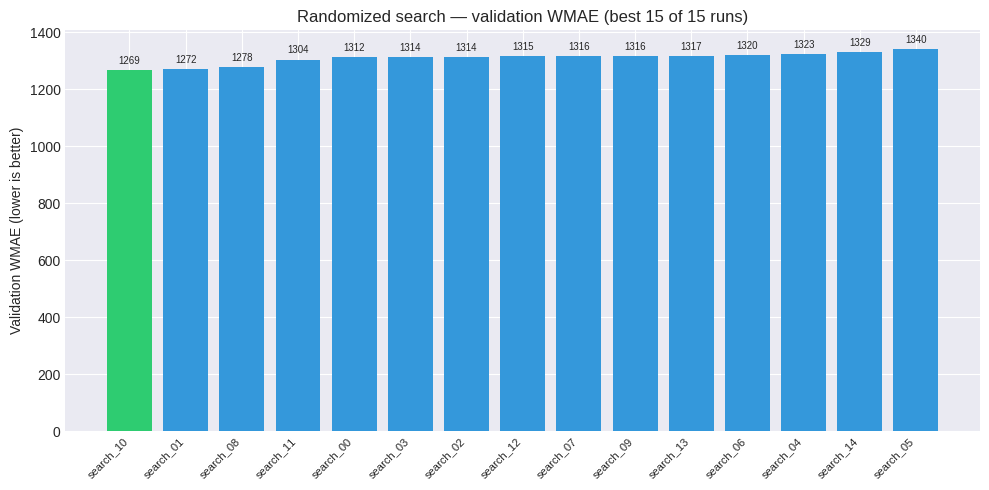

Best config: search_10  (run_id=ec0e19ae0e0f4574ab59fc63f7317224)
val_wmae            1268.8323
train_wmae          1218.1579
num_leaves                187
learning_rate          0.0434
n_estimators             2646
subsample              0.7653
colsample_bytree       0.5429
min_child_samples          66
reg_alpha              0.6376
reg_lambda             2.7180
Name: 0, dtype: object


In [28]:
order = results_df.sort_values("val_wmae").reset_index(drop=True)
top_n = min(20, len(order))
plot_order = order.head(top_n)

fig, ax = plt.subplots(figsize=(max(10, top_n * 0.5), 5))
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(plot_order))]
bars = ax.bar(plot_order["run_name"], plot_order["val_wmae"], color=colors)
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=7)
ax.set_ylabel("Validation WMAE (lower is better)")
ax.set_title(f"Randomized search — validation WMAE (best {top_n} of {len(order)} runs)")
ax.set_xticklabels(plot_order["run_name"], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("/tmp/plot_wmae_comparison.png", dpi=150)
plt.show()

# results_df is already sorted ascending by val_wmae, so row 0 is the winner
BEST_RUN_NAME = results_df.iloc[0]["run_name"]
BEST_RUN_ID   = results_df.iloc[0]["run_id"]
print(f"Best config: {BEST_RUN_NAME}  (run_id={BEST_RUN_ID})")
print(results_df.iloc[0][["val_wmae", "train_wmae", "num_leaves", "learning_rate",
                           "n_estimators", "subsample", "colsample_bytree",
                           "min_child_samples", "reg_alpha", "reg_lambda"]])

## Plot — learning curves (train vs val MAE), top configs

With 25 random configs a full grid is unreadable, so this shows the top
`TOP_N_CURVES` runs by validation WMAE.


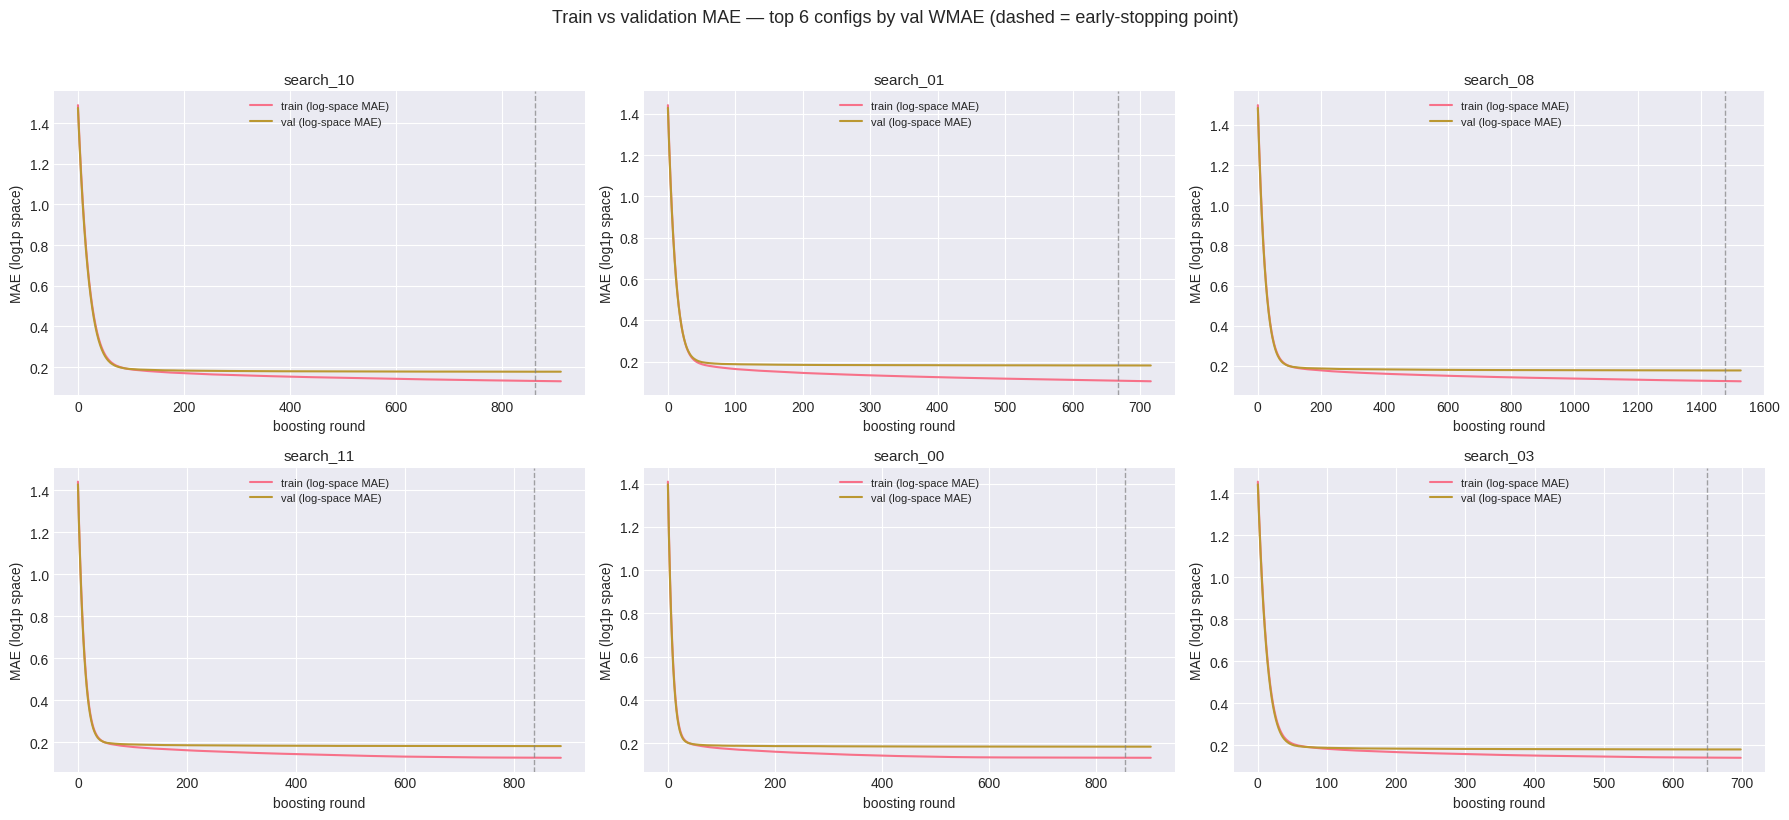

In [29]:
TOP_N_CURVES = 6
top_runs = results_df.sort_values("val_wmae").head(TOP_N_CURVES)["run_name"].tolist()

ncols = 3
nrows = int(np.ceil(TOP_N_CURVES / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for i, run_name in enumerate(top_runs):
    hist = eval_histories[run_name]
    ax = axes[i]
    ax.plot(hist["train"]["l1"], label="train (log-space MAE)", lw=1.5)
    ax.plot(hist["valid"]["l1"], label="val (log-space MAE)", lw=1.5)
    best_it = models[run_name].best_iteration_
    ax.axvline(best_it, color="gray", ls="--", lw=1, alpha=0.7)
    ax.set_title(run_name, fontsize=11)
    ax.set_xlabel("boosting round")
    ax.set_ylabel("MAE (log1p space)")
    ax.legend(fontsize=8)

for j in range(TOP_N_CURVES, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Train vs validation MAE — top {TOP_N_CURVES} configs by val WMAE "
             "(dashed = early-stopping point)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/plot_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Plot — best model: actual vs predicted, and residuals


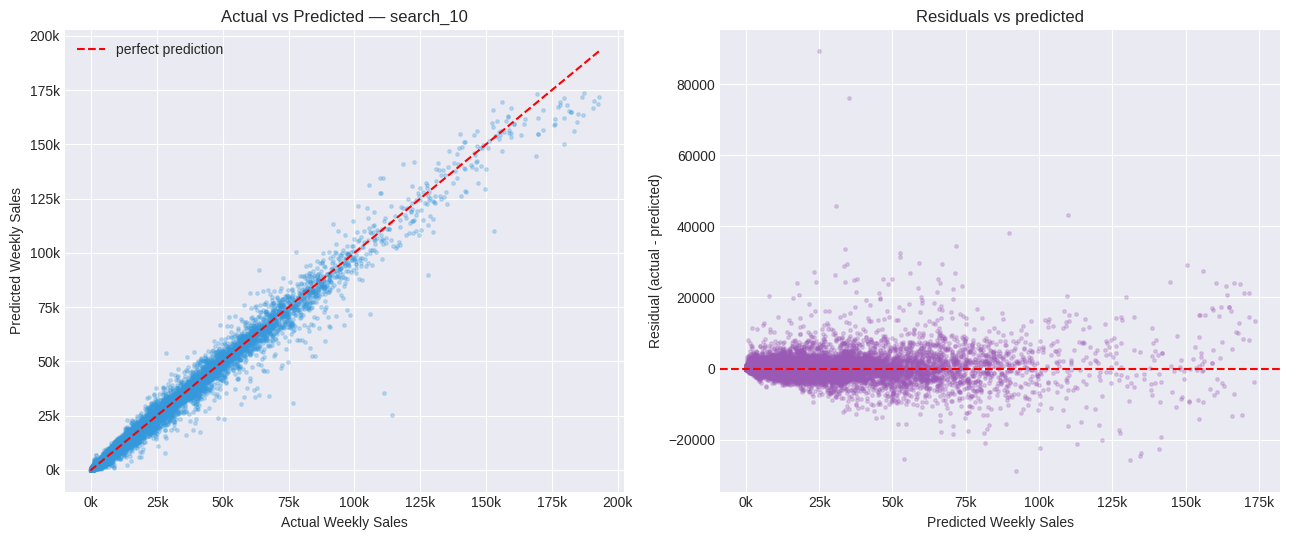

Residual mean: 152.81   Residual std: 2638.56


In [30]:
best_model = models[BEST_RUN_NAME]

# model was trained on log1p(target) — must invert before comparing to real-scale y_val
best_val_pred = np.expm1(best_model.predict(X_val))
residuals = y_val.values - best_val_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(y_val, best_val_pred, s=6, alpha=0.25, color="#3498db")
lims = [min(y_val.min(), best_val_pred.min()), max(y_val.max(), best_val_pred.max())]
ax.plot(lims, lims, color="red", lw=1.5, ls="--", label="perfect prediction")
ax.set_xlabel("Actual Weekly Sales")
ax.set_ylabel("Predicted Weekly Sales")
ax.set_title(f"Actual vs Predicted — {BEST_RUN_NAME}")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax = axes[1]
ax.scatter(best_val_pred, residuals, s=6, alpha=0.25, color="#9b59b6")
ax.axhline(0, color="red", lw=1.5, ls="--")
ax.set_xlabel("Predicted Weekly Sales")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs predicted")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("/tmp/plot_actual_vs_pred.png", dpi=150)
plt.show()

print(f"Residual mean: {residuals.mean():.2f}   Residual std: {residuals.std():.2f}")

## 10. Plot — feature importance (best model)


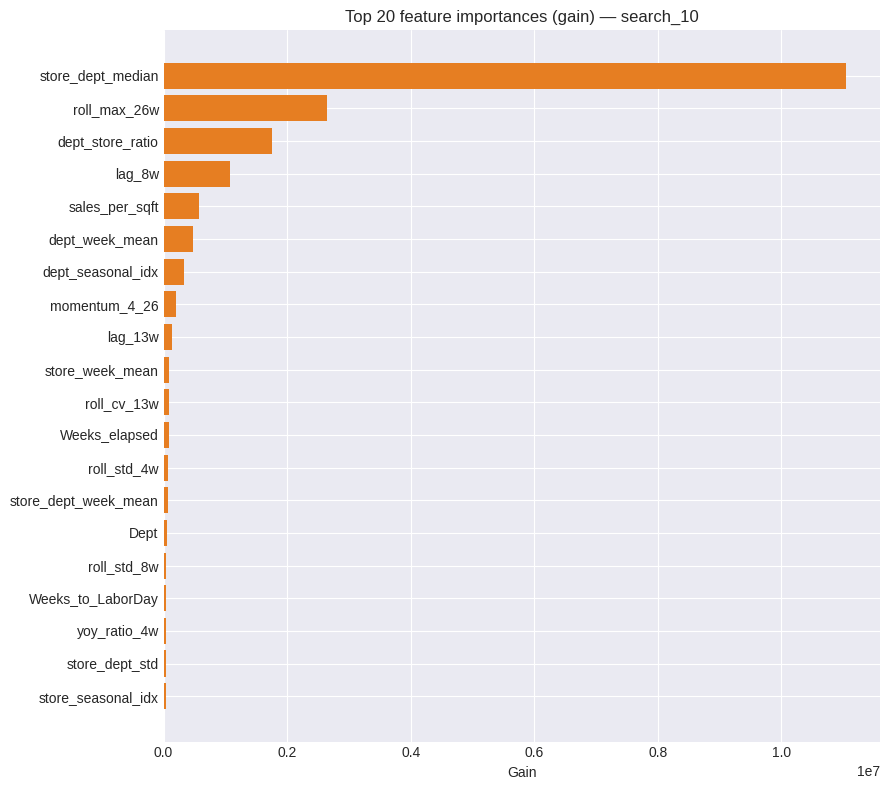

In [31]:
importances = pd.Series(
    best_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
importances = importances.head(20)[::-1]  # reverse for horizontal bar top-to-bottom

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(importances.index, importances.values, color="#e67e22")
ax.set_xlabel("Gain")
ax.set_title(f"Top 20 feature importances (gain) — {BEST_RUN_NAME}")
plt.tight_layout()
plt.savefig("/tmp/plot_feature_importance.png", dpi=150)
plt.show()

## Plot — hyperparameter sensitivity


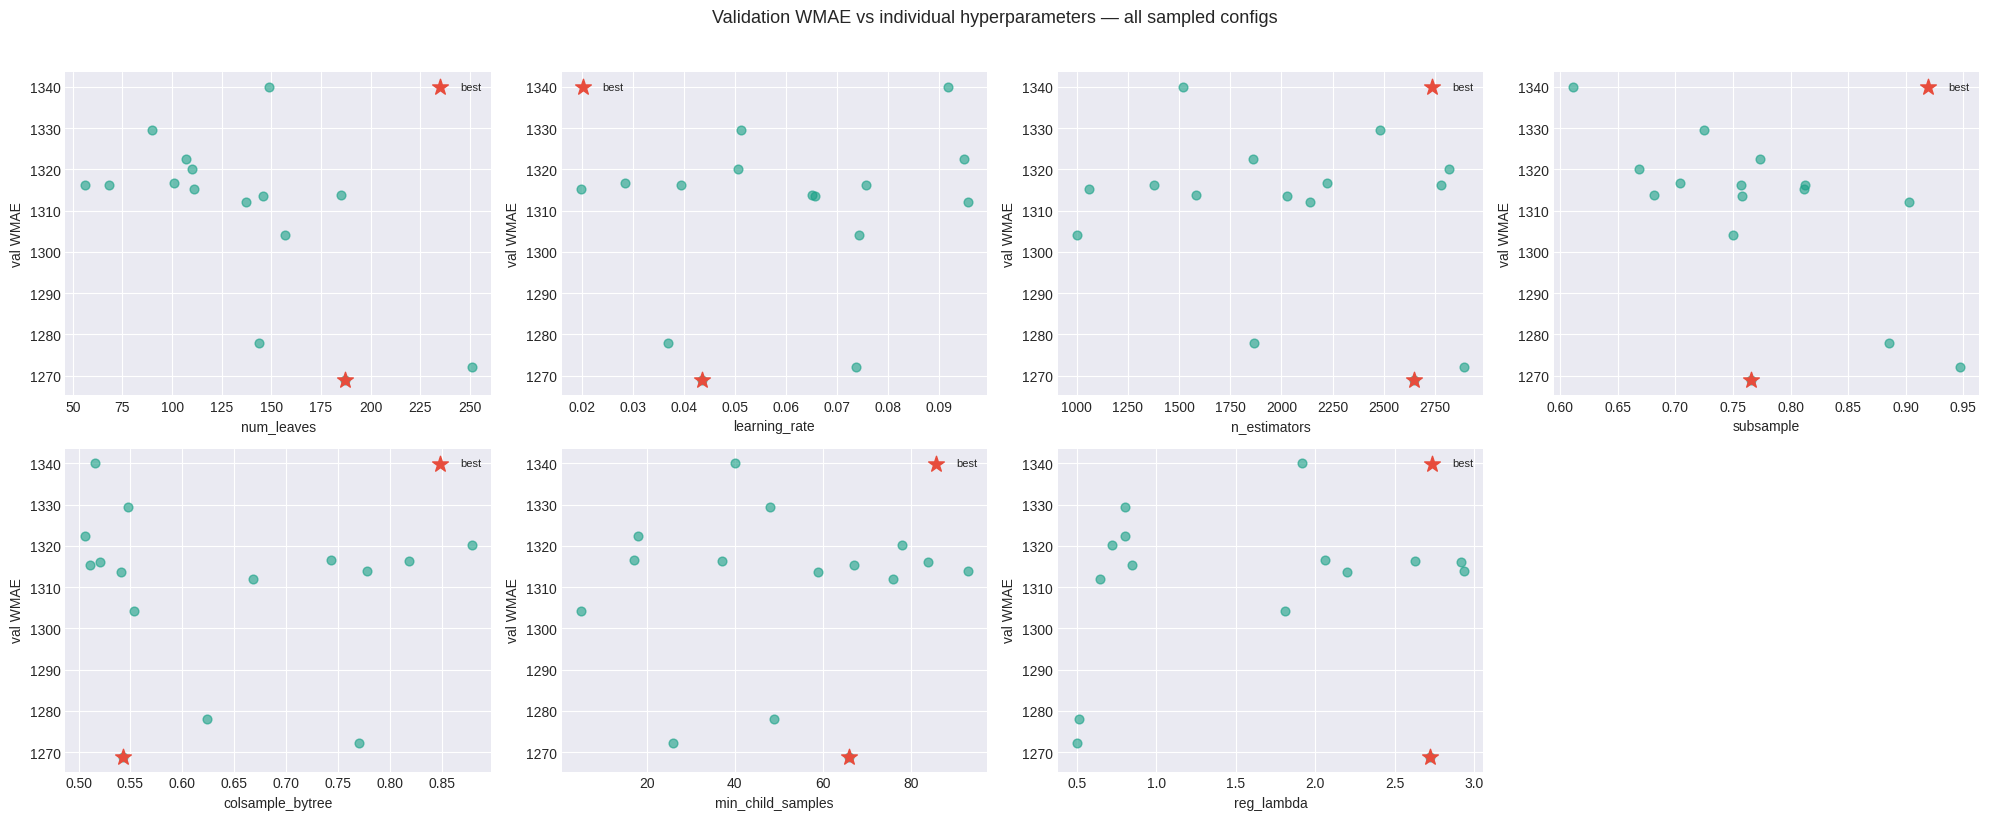

In [32]:
hp_cols = ["num_leaves", "learning_rate", "n_estimators", "subsample",
           "colsample_bytree", "min_child_samples", "reg_lambda"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.reshape(-1)

best_idx = results_df["val_wmae"].idxmin()

for ax, col in zip(axes, hp_cols):
    ax.scatter(results_df[col], results_df["val_wmae"], s=40, alpha=0.6, color="#16a085")
    ax.scatter(results_df.loc[best_idx, col], results_df.loc[best_idx, "val_wmae"],
               s=140, color="#e74c3c", marker="*", zorder=5, label="best")
    ax.set_xlabel(col)
    ax.set_ylabel("val WMAE")
    ax.legend(fontsize=8)

for j in range(len(hp_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle("Validation WMAE vs individual hyperparameters — all sampled configs",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/plot_hyperparam_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot — overfitting gap (train WMAE vs val WMAE)

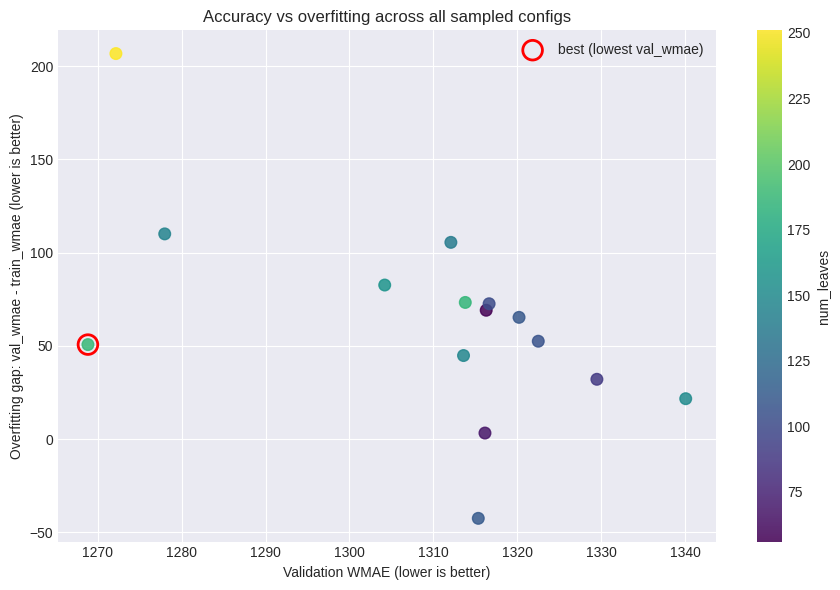

Top 5 by val_wmae:
    run_name  val_wmae      gap
0  search_10 1268.8323  50.6744
1  search_01 1272.1671 206.6760
2  search_08 1277.9829 110.0178
3  search_11 1304.2002  82.5959
4  search_00 1312.0849 105.4750

Top 5 by smallest gap (most robust):
     run_name  val_wmae      gap
7   search_12 1315.3521 -42.4650
8   search_07 1316.1481   3.2596
14  search_05 1340.0718  21.6760
13  search_14 1329.4875  32.0711
5   search_03 1313.5924  44.8049


In [33]:
results_df["gap"] = results_df["val_wmae"] - results_df["train_wmae"]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(results_df["val_wmae"], results_df["gap"],
                 c=results_df["num_leaves"], cmap="viridis", s=70, alpha=0.85)
ax.scatter(results_df.loc[best_idx, "val_wmae"], results_df.loc[best_idx, "gap"],
           s=200, facecolors="none", edgecolors="red", linewidths=2, label="best (lowest val_wmae)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("num_leaves")
ax.set_xlabel("Validation WMAE (lower is better)")
ax.set_ylabel("Overfitting gap: val_wmae - train_wmae (lower is better)")
ax.set_title("Accuracy vs overfitting across all sampled configs")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/plot_overfit_gap.png", dpi=150)
plt.show()

print("Top 5 by val_wmae:")
print(results_df.sort_values("val_wmae")[["run_name", "val_wmae", "gap"]].head())
print("\nTop 5 by smallest gap (most robust):")
print(results_df.sort_values("gap")[["run_name", "val_wmae", "gap"]].head())

## 12. Log a summary run to MLflow

Bundles the results table and every comparison plot as artifacts on a dedicated
`summary` run, and tags it with the winning run's id so it's easy to find later.


In [34]:
with mlflow.start_run(run_name="summary") as summary_run:
    mlflow.set_tag("best_run_name", BEST_RUN_NAME)
    mlflow.set_tag("best_run_id", BEST_RUN_ID)
    mlflow.set_tag("search_type", "randomized")
    mlflow.log_param("n_search_iter", N_SEARCH_ITER)
    mlflow.log_metric("best_val_wmae", float(results_df.iloc[0]["val_wmae"]))
    mlflow.log_metric("best_gap", float(results_df.iloc[0]["gap"]))

    results_csv_path = "/tmp/lightgbm_training_results.csv"
    results_df.to_csv(results_csv_path, index=False)
    mlflow.log_artifact(results_csv_path)

    for p in [
        "/tmp/plot_wmae_comparison.png",
        "/tmp/plot_learning_curves.png",
        "/tmp/plot_actual_vs_pred.png",
        "/tmp/plot_feature_importance.png",
        "/tmp/plot_hyperparam_sensitivity.png",
        "/tmp/plot_overfit_gap.png",
    ]:
        mlflow.log_artifact(p)

    print(f"Summary run logged: {summary_run.info.run_id}")

print("\nAll runs are under the MLflow experiment 'lightgbm_training'.")

Summary run logged: eb5ced6643bf45b08b85eb7bc0b0ea95
🏃 View run summary at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1/runs/eb5ced6643bf45b08b85eb7bc0b0ea95
🧪 View experiment at: https://dagshub.com/nikaduri/ml-store-sales-forecasting.mlflow/#/experiments/1

All runs are under the MLflow experiment 'lightgbm_training'.
